## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import time

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from skopt.utils import use_named_args
from skopt import gp_minimize
from skopt.space import Real, Categorical
from skopt.plots import plot_convergence
import matplotlib.pyplot as plt

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve

## Load Data

In [5]:
df = pd.read_excel("diabetic_data.xlsx")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
df.shape

(101766, 50)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  str   
 3   gender                    101766 non-null  str   
 4   age                       101766 non-null  str   
 5   weight                    101766 non-null  str   
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  str   
 11  medical_specialty         101766 non-null  str   
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_medications

In [8]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [9]:
for col in df.columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== encounter_id ===
encounter_id
2278392      1
149190       1
64410        1
500364       1
16680        1
            ..
443847548    1
443847782    1
443854148    1
443857166    1
443867222    1
Name: count, Length: 101766, dtype: int64

=== patient_nbr ===
patient_nbr
88785891     40
43140906     28
1660293      23
23199021     23
88227540     23
             ..
183087545     1
188574944     1
140199494     1
120975314     1
175429310     1
Name: count, Length: 71518, dtype: int64

=== race ===
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

=== gender ===
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

=== age ===
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)    

## Data Cleaning

#### Input Data Cleaning

In [10]:
# Want to avoid model 'memorising' patient patterns
# Only keep latest encounter_id for duplicate patient_nbr
cleaned_df = (
    df.sort_values('encounter_id', ascending=False)
      .drop_duplicates(subset='patient_nbr', keep='first')
)

cleaned_df = cleaned_df.sort_values('encounter_id').reset_index(drop=True)

In [11]:
# Missing Data
counts = (cleaned_df == '?').sum()
counts[counts > 0]

race                  1878
weight               68671
payer_code           30085
medical_specialty    34525
diag_1                  17
diag_2                 290
diag_3                1146
dtype: int64

In [12]:
### Weight ###

# Drop weight since majority is missing
cleaned_df = cleaned_df.drop(columns=['weight'])

In [13]:
### Payer Code and Medical Specialty ###

# Too many to just add a common value or probalisitic value
# Rather reflect as no value or missing
cleaned_df['payer_code'] = cleaned_df['payer_code'].replace('?', "Missing")
cleaned_df['medical_specialty'] = cleaned_df['medical_specialty'].replace('?', "Missing")

# Drop Payer Code. Has no relevance to readmit
cleaned_df = cleaned_df.drop(columns=['payer_code'])

In [14]:
# Age column is ordinal - encode to median value
encoding = {
    '[90-100)' : 95,  
    '[80-90)'  : 85, 
    '[70-80)'  : 75,
    '[60-70)'  : 65,  
    '[50-60)'  : 55,  
    '[40-50)'  : 45,  
    '[30-40)'  : 35,     
    '[20-30)'  : 25, 
    '[10-20)'  : 15,
    '[0-10)'   : 5 
}

cleaned_df['age'] = cleaned_df['age'].apply(lambda x : encoding[x])

In [15]:
# Drop singe-value columns as they provide no variance and hence do not aid the classification problem
cleaned_df =  cleaned_df.drop(columns=['examide', 'citoglipton', 'glimepiride-pioglitazone'])

In [16]:
# Covert binary columns to 0/1
binary_map = {
    "gender": {"Female": 0, "Male": 1},
    "change": {"No": 0, "Ch": 1},
    "diabetesMed": {"No": 0, "Yes": 1}
}

for col, mapping in binary_map.items():
    cleaned_df[col] = cleaned_df[col].map(mapping)

#### Target encoding

In [17]:
# We only interested in if they readmit within 30 days
readmit_map = {">30": 0, "NO": 0, "<30": 1}
cleaned_df["readmitted"] = cleaned_df["readmitted"].map(readmit_map)

In [18]:
cleaned_df['readmitted'].value_counts(normalize=True)

readmitted
0    0.95492
1    0.04508
Name: proportion, dtype: float64

In [19]:
for col in cleaned_df.columns:
    print(f"\n=== {col} ===")
    print(cleaned_df[col].value_counts(dropna=False))


=== encounter_id ===
encounter_id
12522        1
15738        1
16680        1
28236        1
35754        1
            ..
443847548    1
443847782    1
443854148    1
443857166    1
443867222    1
Name: count, Length: 71518, dtype: int64

=== patient_nbr ===
patient_nbr
48330783     1
63555939     1
42519267     1
89869032     1
82637451     1
            ..
100162476    1
74694222     1
41088789     1
31693671     1
175429310    1
Name: count, Length: 71518, dtype: int64

=== race ===
race
Caucasian          53538
AfricanAmerican    12915
?                   1878
Hispanic            1508
Other               1167
Asian                512
Name: count, dtype: int64

=== gender ===
gender
0.0    38023
1.0    33492
NaN        3
Name: count, dtype: int64

=== age ===
age
75    18162
65    15908
55    12349
85    11864
45     6756
35     2650
95     2040
25     1111
15      525
5       153
Name: count, dtype: int64

=== admission_type_id ===
admission_type_id
1    37191
3    13823
2    13

In [20]:
cleaned_df

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,12522,48330783,Caucasian,0.0,85,2,1,4,13,Missing,...,No,No,Steady,No,No,No,No,1,1,0
1,15738,63555939,Caucasian,0.0,95,3,3,4,12,InternalMedicine,...,No,No,Steady,No,No,No,No,1,1,0
2,16680,42519267,Caucasian,1.0,45,1,1,7,1,Missing,...,No,No,Steady,No,No,No,No,1,1,0
3,28236,89869032,AfricanAmerican,0.0,45,1,1,7,9,Missing,...,No,No,Steady,No,No,No,No,0,1,0
4,35754,82637451,Caucasian,1.0,55,2,1,2,3,Missing,...,No,No,Steady,No,No,No,No,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71513,443847548,100162476,AfricanAmerican,1.0,75,1,3,7,3,Missing,...,No,No,Down,No,No,No,No,1,1,0
71514,443847782,74694222,AfricanAmerican,0.0,85,1,4,5,5,Missing,...,No,No,Steady,No,No,No,No,0,1,0
71515,443854148,41088789,Caucasian,1.0,75,1,1,7,1,Missing,...,No,No,Down,No,No,No,No,1,1,0
71516,443857166,31693671,Caucasian,0.0,85,2,3,7,10,Surgery-General,...,No,No,Up,No,No,No,No,1,1,0


## Split data

In [21]:
# Create input and target
X_cols = cleaned_df.columns.drop(['encounter_id', 'patient_nbr', 'readmitted']).tolist()
y_col = 'readmitted'

In [22]:
# Get fixed test set
test_len = int(len(cleaned_df) * 0.15)
test = cleaned_df.iloc[-test_len:]
train_val = cleaned_df[:len(cleaned_df) - test_len]

X_test = test[X_cols]
y_test = test[y_col]
X_train_val = train_val[X_cols]
y_train_val = train_val[y_col]

## Make Model

In [23]:
# Train/Val/Test specific cleaning
# These columns need to be cleaned in each set to prevent data leakage

### Race ###
# Impute Race using probability of other types

### Diagnoses ###
# Fill diag_1, diag_2 and diag_3 with the most common value
# They have entries such as 'V45' hence we can't use median or mean
# Implement frequency encoding since each one of these cols have over 700 unique values

### Medical Speciality ###
# medical_speciality has a lot of missing, keep only top 10, group rest

class DataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.race_probabilities_ = None
        self.diag_common_ = {}
        self.diag_frequencies_ = {}
        self.top_med_specialties_ = None

    def fit(self, X, y=None):
        X = X.copy()
        
        # 1. Learn Race Probabilities
        race_col = X['race']
        valid_race = race_col[race_col != '?']
        self.race_probabilities_ = valid_race.value_counts(normalize=True)

        # 2. Learn Diagnosis Modes & Frequencies
        for col in ["diag_1", "diag_2", "diag_3"]:
            valid_diags = X.loc[X[col] != '?', col]
            self.diag_common_[col] = valid_diags.mode().iloc[0]                                 # Get most common diagnoses
            self.diag_frequencies_[col] = valid_diags.value_counts(normalize=True)              # Get frequencies of diagnoses

        # 3. Learn Top 10 Specialties
        self.top_med_specialties_ = X['medical_specialty'].value_counts().nlargest(10).index
        
        return self

    def transform(self, X):
        X = X.copy()

        # --- Apply Race Imputation ---
        race_empty = X['race'] == '?'
        if race_empty.any():
            X.loc[race_empty, 'race'] = np.random.choice(
                self.race_probabilities_.index,
                size=race_empty.sum(),
                p=self.race_probabilities_.values
            )

        # --- Apply Diagnosis Cleaning ---
        for col in ["diag_1", "diag_2", "diag_3"]:
            # Replace '?' with most common value
            X[col] = X[col].replace('?', self.diag_common_[col])
            # Map frequencies learned in fit (unseen values get 0)
            X[col] = X[col].map(self.diag_frequencies_[col]).fillna(0)

        # --- Apply Medical Specialty Grouping ---
        X['medical_specialty'] = X['medical_specialty'].where(
            X['medical_specialty'].isin(self.top_med_specialties_), 
            'Other'
        )

        return X

In [24]:
def make_model(dummyclassifier=False, learning_rate=1e-4, tuning=None):
    # Normalize numeric columns
    numeric_cols = [
        "age","time_in_hospital","num_lab_procedures","num_procedures",
        "num_medications","number_outpatient","number_emergency",
        "number_inpatient","diag_1","diag_2","diag_3","number_diagnoses"
    ]

    # One-hot encode categorical columns with few unique values and no order
    categorical_cols = [
        "race","admission_type_id","discharge_disposition_id","admission_source_id", 'medical_specialty', "max_glu_serum", "A1Cresult",
        "metformin","repaglinide","nateglinide","chlorpropamide",
        "glimepiride","acetohexamide","glipizide","glyburide","tolbutamide","pioglitazone",
        "rosiglitazone","acarbose","miglitol","troglitazone",
        "tolazamide","insulin","glyburide-metformin",
        "glipizide-metformin","metformin-rosiglitazone",
        "metformin-pioglitazone"
    ]

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ])
    
    if dummyclassifier:
        model = DummyClassifier(strategy="prior",random_state=42)
    else:
        if tuning == 'GridSearchCV':
            model = SGDClassifier(loss="log_loss", learning_rate="constant", random_state=42)
        elif tuning == 'Bayesian':
            model = SGDClassifier(loss="log_loss", class_weight="balanced", random_state=42)
        else:
            model = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=learning_rate, class_weight="balanced", random_state=42)

    return Pipeline([
        ("cleaner", DataCleaner()),
        ("prep", preprocessor),
        ("model", model)
    ])

In [25]:
def run_model(dummyclassifier=False, learning_rate=1e-4, tuning=None):
    start_time = time.perf_counter()
    results = []

    tscv = TimeSeriesSplit(n_splits=5)

    for fold, (train_index, val_index) in enumerate(tscv.split(X_train_val)):
        X_train, X_val = X_train_val.iloc[train_index], X_train_val.iloc[val_index]
        y_train, y_val = y_train_val.iloc[train_index], y_train_val.iloc[val_index]

        model = make_model(dummyclassifier=dummyclassifier, learning_rate=learning_rate, tuning=tuning)
        model.fit(X_train, y_train)

        # Get probabilities not class labels
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_val_proba = model.predict_proba(X_val)[:, 1]

        # Compute ROC AUC
        roc_train = roc_auc_score(y_train, y_train_proba)
        roc_val = roc_auc_score(y_val, y_val_proba)

        # Compute PR AUC
        pr_train = average_precision_score(y_train, y_train_proba)
        pr_val = average_precision_score(y_val, y_val_proba)

        # Get Recall at Precision >= 0.8 for Val
        precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
        valid = precision[:-1] >= 0.8

        if np.any(valid):
            best_recall = recall[:-1][valid].max()
        else:
            best_recall = 0

        results.append((fold, roc_train, pr_train, roc_val, pr_val, best_recall))

    # Comput Test output probabilities
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Compute Test ROC AUC
    roc_test = roc_auc_score(y_test, y_test_proba)

    # Compute Test PR AUC
    pr_test = average_precision_score(y_test, y_test_proba)

    test_results = [roc_test, pr_test]

    end_time = time.perf_counter()
    runtime = end_time - start_time

    return results, runtime, test_results

## Baseline Model

In [26]:
print("Baseline Classifier \n")

results, runtime, test_results = run_model(dummyclassifier=True)
results_df = pd.DataFrame(results, columns=["fold", "roc_train", "pr_train", "roc_val", "pr_val", "recall_p80"])

print(f'\nRuntime: {runtime} s \n')
print(results_df)
print("\nSD train PR_AUC:", results_df["pr_train"].std())
print("Mean train PR_AUC:", results_df["pr_train"].mean())
print("\nSD val PR_AUC:", results_df["pr_val"].std())
print("Mean val PR_AUC:", results_df["pr_val"].mean())
print("\nTest PR_AUC:", test_results[1])
print("\nSD val Recall@P>=0.8:", results_df["recall_p80"].std())
print("Mean val Recall@P>=0.8:", results_df["recall_p80"].mean())

Baseline Classifier 


Runtime: 0.9122743750003792 s 

   fold  roc_train  pr_train  roc_val    pr_val  recall_p80
0     0        0.5  0.047455      0.5  0.050044           0
1     1        0.5  0.048749      0.5  0.058928           0
2     2        0.5  0.052142      0.5  0.040865           0
3     3        0.5  0.049323      0.5  0.031389           0
4     4        0.5  0.045736      0.5  0.025466           0

SD train PR_AUC: 0.002375262848008674
Mean train PR_AUC: 0.04868087839185871

SD val PR_AUC: 0.013567698752391234
Mean val PR_AUC: 0.04133846609416642

Test PR_AUC: 0.06050153817469936

SD val Recall@P>=0.8: 0.0
Mean val Recall@P>=0.8: 0.0


## SGD Sensitivity: 3 Fixed Learning Rates 

In [27]:
# eta0 = 1e-4
print("SGD Classifier with eta0=1e-4 \n")

results, runtime, test_results = run_model(learning_rate=1e-4)
results_df = pd.DataFrame(results, columns=["fold", "roc_train", "pr_train", "roc_val", "pr_val","recall_p80"])

print(f'\nRuntime: {runtime} s \n')
print(results_df)
print("\nSD train PR_AUC:", results_df["pr_train"].std())
print("Mean train PR_AUC:", results_df["pr_train"].mean())
print("\nSD val PR_AUC:", results_df["pr_val"].std())
print("Mean val PR_AUC:", results_df["pr_val"].mean())
print("\nTest PR_AUC:", test_results[1])
print("\nSD val Recall@P>=0.8:", results_df["recall_p80"].std())
print("Mean val Recall@P>=0.8:", results_df["recall_p80"].mean())

SGD Classifier with eta0=1e-4 


Runtime: 1.3838937919999807 s 

   fold  roc_train  pr_train   roc_val    pr_val  recall_p80
0     0   0.768725  0.144169  0.707880  0.121459    0.000000
1     1   0.768547  0.151988  0.722368  0.147039    0.000000
2     2   0.756455  0.152290  0.687561  0.093602    0.000000
3     3   0.753495  0.146043  0.704901  0.076756    0.003145
4     4   0.741982  0.130904  0.690586  0.059650    0.000000

SD train PR_AUC: 0.008694940342356955
Mean train PR_AUC: 0.1450787905301212

SD val PR_AUC: 0.034935846042190834
Mean val PR_AUC: 0.09970115787972655

Test PR_AUC: 0.10712675419621752

SD val Recall@P>=0.8: 0.0014063320613206226
Mean val Recall@P>=0.8: 0.000628930817610063


In [28]:
# eta0 = 1e-3
print("SGD Classifier with eta0=1e-3 \n")

results, runtime, test_results = run_model(learning_rate=1e-3)
results_df = pd.DataFrame(results, columns=["fold", "roc_train", "pr_train", "roc_val", "pr_val","recall_p80"])

print(f'\nRuntime: {runtime} s \n')
print(results_df)
print("\nSD train PR_AUC:", results_df["pr_train"].std())
print("Mean train PR_AUC:", results_df["pr_train"].mean())
print("\nSD val PR_AUC:", results_df["pr_val"].std())
print("Mean val PR_AUC:", results_df["pr_val"].mean())
print("\nTest PR_AUC:", test_results[1])
print("\nSD val Recall@P>=0.8:", results_df["recall_p80"].std())
print("Mean val Recall@P>=0.8:", results_df["recall_p80"].mean())

SGD Classifier with eta0=1e-3 


Runtime: 1.2452456250002797 s 

   fold  roc_train  pr_train   roc_val    pr_val  recall_p80
0     0   0.801230  0.167339  0.725830  0.135069    0.000000
1     1   0.785333  0.166539  0.733837  0.153220    0.000000
2     2   0.771663  0.165019  0.709521  0.100450    0.000000
3     3   0.761137  0.155357  0.721358  0.087085    0.006289
4     4   0.751895  0.136934  0.689822  0.058927    0.000000

SD train PR_AUC: 0.012843985021626515
Mean train PR_AUC: 0.15823773564735202

SD val PR_AUC: 0.03766540381618674
Mean val PR_AUC: 0.10695029375569962

Test PR_AUC: 0.10689346829544841

SD val Recall@P>=0.8: 0.002812664122641245
Mean val Recall@P>=0.8: 0.001257861635220126


In [29]:
# eta0 = 1e-2
print("SGD Classifier with eta0=1e-2 \n")

results, runtime, test_results = run_model(learning_rate=1e-2)
results_df = pd.DataFrame(results, columns=["fold", "roc_train", "pr_train", "roc_val", "pr_val","recall_p80"])

print(f'\nRuntime: {runtime} s \n')
print(results_df)
print("\nSD train PR_AUC:", results_df["pr_train"].std())
print("Mean train PR_AUC:", results_df["pr_train"].mean())
print("\nSD val PR_AUC:", results_df["pr_val"].std())
print("Mean val PR_AUC:", results_df["pr_val"].mean())
print("\nTest PR_AUC:", test_results[1])
print("\nSD val Recall@P>=0.8:", results_df["recall_p80"].std())
print("Mean val Recall@P>=0.8:", results_df["recall_p80"].mean())

SGD Classifier with eta0=1e-2 


Runtime: 1.227133958000195 s 

   fold  roc_train  pr_train   roc_val    pr_val  recall_p80
0     0   0.794480  0.160787  0.715592  0.129059    0.001972
1     1   0.754858  0.151620  0.712162  0.139857    0.000000
2     2   0.748380  0.148522  0.693896  0.096541    0.000000
3     3   0.706108  0.132641  0.681030  0.082851    0.003145
4     4   0.714508  0.109492  0.672947  0.050866    0.000000

SD train PR_AUC: 0.020141835994805003
Mean train PR_AUC: 0.14061243107103477

SD val PR_AUC: 0.03589226077952337
Mean val PR_AUC: 0.09983483498810684

Test PR_AUC: 0.08786002192847667

SD val Recall@P>=0.8: 0.0014613638432564371
Mean val Recall@P>=0.8: 0.0010234081351643038


## Grid Search over SGD Hyperparameters

In [30]:
# Define parameter Grid

param_grid = {
    "model__eta0": [1e-4,3e-4,1e-3,3e-3,1e-2],
    "model__alpha": [1e-6,1e-5,1e-4,1e-3],
    "model__penalty":["l2", "l1"],
    "model__class_weight": [None, "balanced"]
}

In [31]:
# Run Grid search

tscv = TimeSeriesSplit(n_splits=5)

model = make_model(tuning='GridSearchCV')

grid = GridSearchCV(
    model,
    param_grid,
    cv=tscv,
    scoring="average_precision", 
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_val, y_train_val)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.2s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.3s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l1; total time=   0.2s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.4s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l1; total time=   0.3s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0003, model__penalty=l2; total time=   0.2s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.6s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l1; total time=   0.4s
[CV] END model__alpha=1e-06, model

In [32]:
# Get Grid results

grid_results = pd.DataFrame(grid.cv_results_)

summary = grid_results[[
    "rank_test_score",
    "param_model__eta0",
    "param_model__alpha",
    "param_model__penalty",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "mean_fit_time"
]].copy()

summary = summary.rename(columns={
    "rank_test_score": "Rank",
    "param_model__eta0": "eta0",
    "param_model__alpha": "alpha",
    "param_model__penalty": "penalty",
    "param_model__class_weight": "class_weight",
    "mean_test_score": "Mean Val PR-AUC",
    "std_test_score": "Std Val PR-AUC",
    "mean_fit_time": "Runtime (s)"
})

summary = summary.sort_values("Rank")

summary

,Rank,eta0,alpha,penalty,class_weight,Mean Val PR-AUC,Std Val PR-AUC,Runtime (s)
57,1,0.0030,0.000100,l1,balanced,0.108780,0.031756,0.420558
37,2,0.0030,0.000010,l1,balanced,0.108585,0.030991,0.402810
17,3,0.0030,0.000001,l1,balanced,0.108548,0.030906,0.395761
56,4,0.0030,0.000100,l2,balanced,0.108487,0.031021,0.361447
16,5,0.0030,0.000001,l2,balanced,0.108486,0.030697,0.349930
...,...,...,...,...,...,...,...,...
21,76,0.0001,0.000010,l1,NaN,0.093139,0.028478,0.297764
40,77,0.0001,0.000100,l2,NaN,0.093126,0.028478,0.293851
1,78,0.0001,0.000001,l1,NaN,0.093119,0.028516,0.372105
41,79,0.0001,0.000100,l1,NaN,0.092996,0.028378,0.321932


In [33]:
# Get best configuration and its test score

best_model_grid = grid.best_estimator_

y_test_proba_grid = best_model_grid.predict_proba(X_test)[:, 1]

roc_test_grid = roc_auc_score(y_test, y_test_proba_grid)
pr_test_grid  = average_precision_score(y_test, y_test_proba_grid)

print("Final Test PR-AUC:", pr_test_grid)

Final Test PR-AUC: 0.09727923972975995


## Bayesian Optimization

In [34]:
# Create search space

space = [
    Real(1e-5, 1e-1, prior="log-uniform", name="eta0"),
    Real(1e-7, 1e-2, prior="log-uniform", name="alpha"),
    Categorical(["l1", "l2"], name="penalty"),
    Categorical(["constant", "optimal", "invscaling", "adaptive"], name="learning_rate")
]

In [35]:
# Custom function for using skopt.gp_minimize

@use_named_args(space)
def objective(eta0, alpha, penalty, learning_rate):
    results = []

    tscv = TimeSeriesSplit(n_splits=5)

    for fold, (train_index, val_index) in enumerate(tscv.split(X_train_val)):
        X_train, X_val = X_train_val.iloc[train_index], X_train_val.iloc[val_index]
        y_train, y_val = y_train_val.iloc[train_index], y_train_val.iloc[val_index]

        model = make_model(tuning='Bayesian')
        model.set_params(
            model__eta0=eta0,
            model__alpha=alpha,
            model__penalty=penalty,
            model__learning_rate=learning_rate
        )

        model.fit(X_train, y_train)

        y_val_proba = model.predict_proba(X_val)[:,1]

        pr_val = average_precision_score(y_val, y_val_proba)
        results.append(pr_val)

    return -np.mean(results)

In [36]:
# Run Bayesian Optimization

result = gp_minimize(
    objective,
    space,
    n_calls=40,
    random_state=42
)

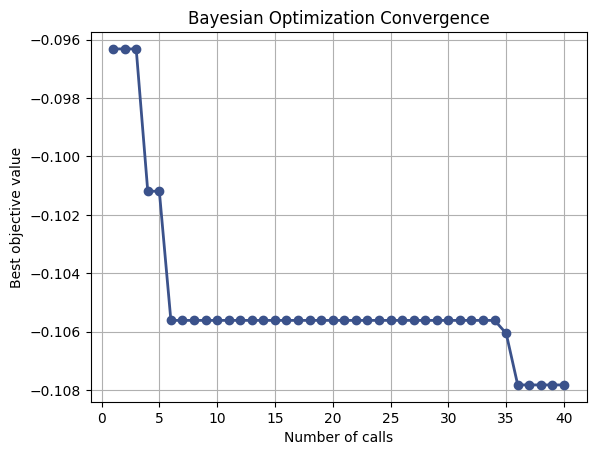

In [37]:
# Convergance plot of best score achieved versus trial number
plot_convergence(result)

plt.xlabel("Number of calls")
plt.ylabel("Best objective value")
plt.title("Bayesian Optimization Convergence")
plt.show()

In [38]:
# Get best configuration

best_params = {
    "eta0": result.x[0],
    "alpha": result.x[1],
    "penalty": result.x[2],
    "learning": result.x[3]
}

print(best_params)
print("Best val PR-AUC:", -result.fun)

{'eta0': 0.0004185167939502599, 'alpha': 0.0003105931829560724, 'penalty': np.str_('l2'), 'learning': np.str_('optimal')}
Best val PR-AUC: 0.10782289723967522


In [39]:
# Get test results

best_model_bayesian = make_model(tuning='Bayesian')

best_model_bayesian.set_params(
    model__eta0=best_params["eta0"],
    model__alpha=best_params["alpha"],
    model__penalty=best_params["penalty"],
    model__learning_rate=best_params["learning"]
)

best_model_bayesian.fit(X_train_val, y_train_val)

y_test_proba_bayesian = best_model_bayesian.predict_proba(X_test)[:,1]

pr_test_bayesian = average_precision_score(y_test, y_test_proba_bayesian)

print("Final Test PR-AUC:", pr_test_bayesian)

Final Test PR-AUC: 0.11164424714067275


## Succesive Halving

In [40]:
# Run HalvingGridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

half_grid = HalvingGridSearchCV(
    estimator=make_model(tuning='GridSearchCV'),
    param_grid=param_grid,
    scoring="average_precision",
    factor=3,
    cv=tscv,
    n_jobs=-1,
    verbose=2
)

half_grid.fit(X_train_val, y_train_val)
print("Best params:", half_grid.best_params_)
print("Best score:", half_grid.best_score_)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 2251
max_resources_: 60791
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 80
n_resources: 2251
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.0s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.0s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.0s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.0s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l2; total time=   0.0s
[CV] END model__alpha=1e-06, model__class_weight=None, model__eta0=0.0001, model__penalty=l1; total time=   0.0s
[CV] END model__alpha=1e-06, model__class_weight=None, mo

In [41]:
# Get HalfGrid results

half_grid_results = pd.DataFrame(half_grid.cv_results_)

summary = half_grid_results[[
    "rank_test_score",
    "param_model__eta0",
    "param_model__alpha",
    "param_model__penalty",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "mean_fit_time"
]].copy()

summary = summary.rename(columns={
    "rank_test_score": "Rank",
    "param_model__eta0": "eta0",
    "param_model__alpha": "alpha",
    "param_model__penalty": "penalty",
    "param_model__class_weight": "class_weight",
    "mean_test_score": "Mean Val PR-AUC",
    "std_test_score": "Std Val PR-AUC",
    "mean_fit_time": "Runtime (s)"
})

summary = summary.sort_values("Rank")

summary

,Rank,eta0,alpha,penalty,class_weight,Mean Val PR-AUC,Std Val PR-AUC,Runtime (s)
82,1,0.0030,0.000001,l1,balanced,0.109446,0.033009,0.052579
118,2,0.0010,0.001000,l1,balanced,0.107610,0.033277,0.416001
116,3,0.0010,0.000001,l1,balanced,0.105567,0.033425,0.385502
117,4,0.0010,0.000100,l1,balanced,0.105184,0.033932,0.485478
111,5,0.0010,0.001000,l1,balanced,0.102652,0.014907,0.161277
...,...,...,...,...,...,...,...,...
0,115,0.0001,0.000001,l2,NaN,0.068301,0.031027,0.016154
61,116,0.0001,0.001000,l1,NaN,0.067863,0.030574,0.017999
1,117,0.0001,0.000001,l1,NaN,0.067553,0.030369,0.018089
20,118,0.0001,0.000010,l2,NaN,0.067074,0.029939,0.016418


In [42]:
# Get best configuration and its test score
best_model_half_grid = half_grid.best_estimator_

y_test_proba_half_grid = best_model_half_grid.predict_proba(X_test)[:, 1]

roc_test__half_grid = roc_auc_score(y_test, y_test_proba_half_grid)
pr_test_half_grid  = average_precision_score(y_test, y_test_proba_half_grid)

print("Final Test PR-AUC:", pr_test_half_grid)

Final Test PR-AUC: 0.11087002616133457
